# The measles heat map, rebuilt from the CDC counts

In February 2015, during the Disneyland measles outbreak, the *Wall Street Journal* published a
set of heat maps under the headline **Battling Infectious Diseases in the 20th Century: The Impact
of Vaccines**. One of them is probably the most-shared statistical graphic of the decade. This
notebook rebuilds it from `us_diseases.csv`, and checks the rebuild against the published image
sitting next to it in this folder (`measles_WSJ.jpg`).

**What the drawing encodes.** One row per state, one column per year, and the colour of each cell
is the measles incidence -- cases per 100,000 people -- in that state in that year. States run top
to bottom in **postal-code** order (AK, AL, AR, AZ, CA ...), which is why Iowa sits above
Illinois. Years run left to right from 1928. A single black rule marks 1963, the year the vaccine
was licensed. Blank cells are state-years nobody counted.

**Why it works.** No trend line, no annotation of the mechanism, no statistical test. The chart
makes its argument entirely by *interruption*: fifty-odd noisy rows of orange and red that all
stop at the same vertical line, and the reader supplies the causal claim unprompted. Nothing in
the encoding is clever -- it is the plainest possible grid -- and that is the point. The structure
was already in the data; the designer's job was to not get in its way.

Be clear about what the chart does *not* establish. It shows a coincidence in time across
fifty-one series at once, which is a great deal more than a single national time series would
show, but it is still an observational before-and-after, not a trial. The evidence that the
vaccine works comes from elsewhere. The chart's job is to make that evidence *legible*.

## 1. The data

`us_diseases.csv` is the Project Tycho / CDC extract: weekly notifiable-disease reports collected
by state and rolled up to the year. Fifty-one states (the fifty plus the District of Columbia)
and four numbers per row.

| column | meaning |
| --- | --- |
| `count` | cases reported that year |
| `population` | state population that year |
| `weeks_reporting` | how many of the 52 weeks the state actually filed a report |
| `year`, `state`, `disease` | the keys |

In [2]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, Normalize

HERE = Path.cwd()                       # run the notebook from its own folder
CSV = HERE / "us_diseases.csv"
IMAGES = HERE / "images"
IMAGES.mkdir(exist_ok=True)

mpl.rcParams["font.family"] = ["Arial", "DejaVu Sans"]

df = pd.read_csv(CSV)
print(df.shape)
df.groupby("disease").agg(rows=("count", "size"), first=("year", "min"),
                          last=("year", "max"), cases=("count", "sum"))

(18870, 6)


,rows,first,last,cases
disease,,,,
Hepatitis A,2346,1966,2011,976362
Measles,3876,1928,2003,18670996
Mumps,1836,1968,2003,832110
Pertussis,3774,1938,2011,2329020
Polio,3774,1938,2011,2329020
Rubella,1938,1966,2003,434966
Smallpox,1326,1928,1953,232828


### Check the source before drawing it

Seven labels, but not seven series. Before any of this gets plotted it is worth asking whether
the file says what its column headings claim.

In [3]:
# Are any two diseases the same numbers under different labels?
keyed = {d: g.set_index(["state", "year"])["count"]
         for d, g in df.groupby("disease")}

names = sorted(keyed)
for i, a in enumerate(names):
    for b in names[i + 1:]:
        common = keyed[a].index.intersection(keyed[b].index)
        if len(common) == 0:
            continue
        same = int((keyed[a].loc[common] == keyed[b].loc[common]).sum())
        if same == len(common):
            print("!! %s and %s are IDENTICAL across all %d shared cells"
                  % (a, b, len(common)))

!! Pertussis and Polio are IDENTICAL across all 3774 shared cells


`Pertussis` and `Polio` are byte-for-byte the same series -- all 3,774 state-years, all 2.33
million cases. At most one of them is what its label says.

The magnitudes say which. Pertussis ran in the hundreds of cases per 100,000 before the DTP
vaccine; US polio, even in the terrible 1952 season, ran in the tens. A series totalling 2.33
million cases over 1938-2011 is pertussis. So the `Polio` rows in this file are a mislabelled
copy, and the polio panel is dropped from the gallery below rather than drawn as though it were
real.

This is not a detour. A heat map is a *very* persuasive object -- fifty-one rows of evidence,
apparently -- and it will render a duplicated series just as confidently as a real one. The check
above costs six lines.

## 2. The number in each cell

`count` on its own will not do. California in 1940 had 7 million people and Wyoming had 250,000,
so raw counts would draw a map of where Americans lived. The cell value is a rate:

$$\text{rate} = \frac{\text{count}}{\text{population}} \times 100{,}000$$

Then there is `weeks_reporting`, and what the WSJ did with it is the interesting part.

A state that filed reports for only 30 weeks of 1945 reported roughly 30/52 of its cases. There
are two defensible responses. **Scale the count up** to a full year (`x 52/weeks`) and keep the
cell. Or **treat the column as a validity flag**: trust the years that were fully reported, blank
the ones that were not, and do no arithmetic on the rest.

The published chart takes the second route -- and takes it strictly. Sampling its colours back
through its own colour bar (the check in section 8 does this) gives a maximum of about 2,930 per
100,000; the unscaled rate peaks at 2,964, the scaled one at 3,670. It is the unscaled rate. And
every cell with `weeks_reporting == 0` is drawn blank, while cells with a genuine zero count are
drawn as pale blue. "Nobody counted" and "nobody got sick" are different facts, and the chart
keeps them apart.

That combination -- use the column to *exclude*, never to *adjust* -- is the conservative choice.
Scaling a 30-week year up to 52 assumes the missing 22 weeks looked like the 30 that were filed,
and for a disease with sharp seasonal epidemics that assumption can be badly wrong in either
direction. Section 3 shows what the choice is worth in practice.

In [4]:
# Postal codes: the WSJ orders states by two-letter abbreviation, not by full
# name -- which is why Iowa (IA) sits above Illinois (IL) on the finished chart.
POSTAL = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District Of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY",
}

# The newspaper's own short forms for the axis -- AP style, not postal codes.
SHORT = {
    "Alabama": "Ala.", "Alaska": "Alaska", "Arizona": "Ariz.", "Arkansas": "Ark.",
    "California": "Calif.", "Colorado": "Colo.", "Connecticut": "Conn.",
    "Delaware": "Del.", "District Of Columbia": "D.C.", "Florida": "Fla.",
    "Georgia": "Ga.", "Hawaii": "Hawaii", "Idaho": "Idaho", "Illinois": "Ill.",
    "Indiana": "Ind.", "Iowa": "Iowa", "Kansas": "Kan.", "Kentucky": "Ky.",
    "Louisiana": "La.", "Maine": "Maine", "Maryland": "Md.", "Massachusetts": "Mass.",
    "Michigan": "Mich.", "Minnesota": "Minn.", "Mississippi": "Miss.",
    "Missouri": "Mo.", "Montana": "Mont.", "Nebraska": "Neb.", "Nevada": "Nev.",
    "New Hampshire": "N.H.", "New Jersey": "N.J.", "New Mexico": "N.M.",
    "New York": "N.Y.", "North Carolina": "N.C.", "North Dakota": "N.D.",
    "Ohio": "Ohio", "Oklahoma": "Okla.", "Oregon": "Ore.", "Pennsylvania": "Pa.",
    "Rhode Island": "R.I.", "South Carolina": "S.C.", "South Dakota": "S.D.",
    "Tennessee": "Tenn.", "Texas": "Texas", "Utah": "Utah", "Vermont": "Vt.",
    "Virginia": "Va.", "Washington": "Wash.", "West Virginia": "W.Va.",
    "Wisconsin": "Wis.", "Wyoming": "Wyo.",
}


def rate(d, scale_by_weeks=False):
    """Cases per 100,000. NaN where nobody reported -- never zero."""
    r = d["count"] / d["population"] * 1e5
    if scale_by_weeks:
        r = r * 52 / d["weeks_reporting"]
    return r.where(d["weeks_reporting"] > 0)      # 0 weeks -> NaN either way


def grid(disease, scale_by_weeks=False):
    """States x years matrix, in the WSJ's row order and with no gaps in the columns."""
    d = df[df["disease"] == disease].copy()
    d["rate"] = rate(d, scale_by_weeks)

    wide = d.pivot(index="state", columns="year", values="rate")
    wide = wide.reindex(sorted(wide.index, key=POSTAL.get))      # postal-code order
    return wide.reindex(columns=range(int(d["year"].min()), int(d["year"].max()) + 1))


measles = grid("Measles")
print("states x years: %d x %d" % measles.shape)
print("years:          %d to %d" % (measles.columns.min(), measles.columns.max()))
print("blank cells:    %d of %d" % (measles.isna().sum().sum(), measles.size))
print("worst cell:     %.0f per 100,000, %s %d"
      % ((measles.max().max(),) + measles.stack().idxmax()))
print("median cell:    %.0f per 100,000" % measles.stack().median())

states x years: 51 x 76
years:          1928 to 2003
blank cells:    557 of 3876
worst cell:     2964 per 100,000, Vermont 1936
median cell:    60 per 100,000


## 3. What the weeks-reporting choice is worth

Worth measuring rather than assuming. The natural guess is that reporting was ragged in the 1930s
and tightened up later, which would put the correction right where the chart is hottest. The data
says the opposite.

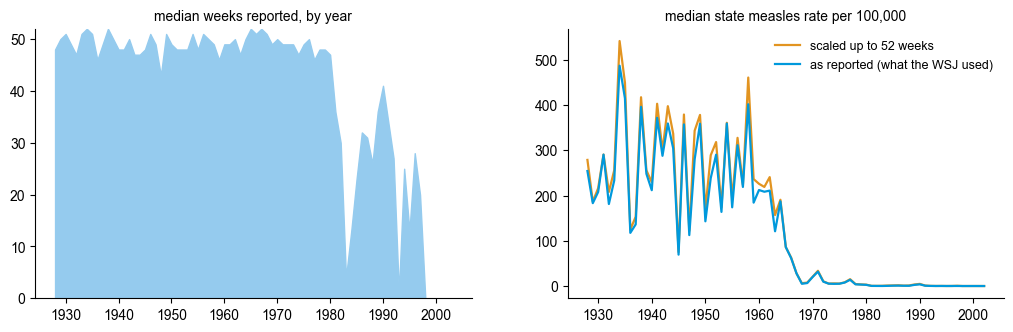

1928-1969  median weeks 49 (4% of cells report nothing at all)
           scaling inflates the median drawn cell x1.06, the 95th percentile x1.49
           worst drawn cell 2964 -> 3670 per 100,000
1980-2003  median weeks 22 (37% of cells report nothing at all)
           scaling inflates the median drawn cell x1.44, the 95th percentile x17.33
           worst drawn cell   43 ->  514 per 100,000


In [5]:
m = df[df["disease"] == "Measles"].copy()
m["plain"] = rate(m)
m["scaled"] = rate(m, scale_by_weeks=True)

by_year = m.groupby("year").agg(weeks=("weeks_reporting", "median"),
                                plain=("plain", "median"),
                                scaled=("scaled", "median"))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.5))
fig.subplots_adjust(wspace=0.22)

axes[0].fill_between(by_year.index, by_year["weeks"], color="#95cbee")
axes[0].set_ylim(0, 52)
axes[0].set_title("median weeks reported, by year", size=10)

axes[1].plot(by_year.index, by_year["scaled"], color="#e29421", lw=1.6,
             label="scaled up to 52 weeks")
axes[1].plot(by_year.index, by_year["plain"], color="#0099dc", lw=1.6,
             label="as reported (what the WSJ used)")
axes[1].legend(frameon=False, fontsize=9)
axes[1].set_title("median state measles rate per 100,000", size=10)

for ax in axes:
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
plt.show()

for lo, hi in [(1928, 1969), (1980, 2003)]:
    era = m[(m["year"] >= lo) & (m["year"] <= hi)]
    kept = era.dropna(subset=["plain"])                 # the cells that get drawn
    blow = kept["scaled"] / kept["plain"]
    print("%d-%d  median weeks %2.0f (%.0f%% of cells report nothing at all)\n"
          "           scaling inflates the median drawn cell x%.2f, the 95th percentile "
          "x%.2f\n           worst drawn cell %4.0f -> %4.0f per 100,000"
          % (lo, hi, era["weeks_reporting"].median(),
             (era["weeks_reporting"] == 0).mean() * 100,
             blow.median(), blow.quantile(0.95),
             kept["plain"].max(), kept["scaled"].max()))

Weekly reporting held up well for forty years -- a median of around 49 weeks of 52 from 1928 all
the way through the 1970s -- and then **collapsed in the 1980s**, falling to a median of 22 weeks
in the 1990s and to zero by the 2000s. Which makes sense: once measles was gone, filing a weekly
return of no cases stopped feeling urgent.

That timing is what makes the WSJ's choice safe, and it is the reverse of the intuition. Through
1969 -- the entire hot half of the chart -- scaling would inflate the median cell by 6%, which is
nothing. After 1980 it would inflate the 95th-percentile cell **seventeen-fold**, turning a worst
case of 43 per 100,000 into 514.

So scaling would not have brightened the epidemic years. It would have manufactured colour in the
post-vaccine tail, out of states that had stopped reporting precisely *because* there was nothing
left to report -- and that stretch of pale blue is the chart's entire punchline. The conservative
choice is not merely defensible here; the persuasive version of the chart depends on it.

The rest of this notebook uses the unscaled rate, to match the published chart.

## 4. The colour scale

This is the one piece of the chart that is *not* obvious, and it is where most reproductions go
wrong.

Measles rates are extremely skewed: the median state-year is about 60 per 100,000, the worst is
2,964. A linear ramp across that range would paint nine cells in ten the same pale colour and the
chart would be empty. A log scale would fix the skew but would also flatten the difference between
a bad year and a catastrophic one, which is the comparison the chart exists to make.

The answer is a **linear axis with non-linearly spaced colour stops**. The numbers stay linear --
the colour bar is evenly spaced from 0 to 4,000, so nobody is asked to decode a transformation --
but the colours are crowded into the bottom eighth of the range, where almost all the data lives.
Blue through green through yellow is spent entirely between 0 and 600; everything above 2,000 is
the same red.

The stops below are sampled straight off the published colour bar. `#e29421` appears twice: that
holds orange flat from 1,000 to 1,600 so the step up to red at 2,000 lands as a step rather than a
gradient. And the bar runs to 4,000 although nothing in the data reaches 3,000 -- a round number
was worth more than a tight one, on a scale nobody is meant to read values off.

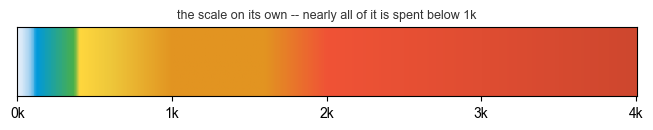

In [6]:
# position on the 0-4,000 axis  ->  colour
STOPS = [
    (0.00, "#e7f0fa"),   #     0  near-white
    (0.01, "#c9e2f6"),   #    40
    (0.02, "#95cbee"),   #    80
    (0.03, "#0099dc"),   #   120  blue
    (0.09, "#4ab04a"),   #   360  green
    (0.10, "#ffd73e"),   #   400  yellow
    (0.15, "#eec73a"),   #   600
    (0.25, "#e29421"),   # 1,000  orange
    (0.40, "#e29421"),   # 1,600  ... held flat
    (0.50, "#f05336"),   # 2,000  red
    (1.00, "#ce472e"),   # 4,000  dark red
]

VMAX = 4000
CMAP = LinearSegmentedColormap.from_list("wsj", STOPS, N=512)
CMAP.set_bad("#f6f6f6")          # nobody counted
NORM = Normalize(vmin=0, vmax=VMAX)

INK = "#333333"                  # tick labels
RULE = "#aaaaaa"                 # axis line and ticks

fig, ax = plt.subplots(figsize=(8, 0.9))
ax.imshow(np.linspace(0, VMAX, 400).reshape(1, -1), aspect="auto", cmap=CMAP, norm=NORM)
ax.set_yticks([])
ax.set_xticks(np.linspace(0, 399, 5))
ax.set_xticklabels(["0k", "1k", "2k", "3k", "4k"])
ax.set_title("the scale on its own -- nearly all of it is spent below 1k", size=9, color=INK)
plt.show()

## 5. The drawing

Everything else is layout. A few decisions worth naming, because they are the difference between
this and a default heat-map call:

- **`pcolormesh` with white edges.** The thin white gutter between cells is what makes 3,876
  rectangles read as a grid of discrete year-by-state facts rather than as a continuous image.
- **No frame, no gridlines, no y tick marks.** The cells *are* the grid.
- **Every other state labelled.** Fifty-one labels at a legible size would not fit; twenty-six do,
  and the reader only needs enough anchors to navigate.
- **The rule drawn on top and extended past the top row**, with its label outside the plot. It is
  annotation, not data, and it must not look like another row.
- **A short colour bar, centred, small.** It is a footnote. The chart is not asking anyone to read
  values off it.

The axes are placed with `add_axes` rather than left to `tight_layout`, so the colour bar and the
note sit in fixed positions underneath the way they do on the printed page.

In [7]:
def heatmap(wide, title, note, mark=None, mark_label="Vaccine introduced",
            norm=None, label_every=2, figsize=(13.3, 10.0)):
    """The WSJ grid: states down, years across, one rule for the intervention."""
    norm = NORM if norm is None else norm
    years = wide.columns.to_numpy()
    states = list(wide.index)

    fig = plt.figure(figsize=figsize, facecolor="white")
    ax = fig.add_axes([0.078, 0.210, 0.914, 0.682])

    # Cell edges half a year either side of each year, so ticks land on centres.
    xe = np.append(years - 0.5, years[-1] + 0.5)
    ye = np.arange(len(states) + 1)

    ax.pcolormesh(xe, ye, np.ma.masked_invalid(wide.to_numpy()),
                  cmap=CMAP, norm=norm, edgecolors="white", linewidth=0.6)

    ax.set_ylim(len(states), 0)                      # first state at the top
    ax.set_xlim(xe[0], xe[-1])

    first = int(np.ceil(years[0] / 10.0) * 10)
    ticks = list(range(first, int(years[-1]) + 1, 10))
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks], size=11.5, color=INK)
    ax.tick_params(axis="x", length=5, width=0.9, color=RULE, pad=5)

    rows = range(0, len(states), label_every)
    ax.set_yticks([r + 0.5 for r in rows])
    ax.set_yticklabels([SHORT[states[r]] for r in rows], size=10.5, color=INK)
    ax.tick_params(axis="y", length=0, pad=4)

    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(RULE)
    ax.spines["bottom"].set_linewidth(0.9)

    if mark is not None:
        # Through the centre of the licensing year, not along its edge. That
        # bisects a cell, which is ugly -- but the alternative implies the
        # vaccine was available for all of 1963, and it was not.
        ax.plot([mark, mark], [len(states), -1.4], color="black", lw=2.4,
                solid_capstyle="butt", clip_on=False, zorder=5)
        # Centred over the rule, except near the edges: on the left the label
        # would run into the title, on the right it would run off the page.
        frac = (mark - xe[0]) / (xe[-1] - xe[0])
        ha = "left" if frac < 0.30 else ("right" if frac > 0.85 else "center")
        pad = {"left": 0.7, "right": -0.7, "center": 0.0}[ha]
        ax.text(mark + pad, -2.1, mark_label, ha=ha, va="bottom",
                size=12.5, color="#222222")

    fig.text(0.014, 0.938, title, size=27, weight="bold", color="#222222", va="center")

    # ---- colour bar: a footnote, not an instrument -------------------------
    cax = fig.add_axes([0.401, 0.143, 0.226, 0.015])
    cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=CMAP),
                      cax=cax, orientation="horizontal")
    cb.outline.set_visible(False)
    cax.tick_params(length=5, width=0.9, color=RULE, labelsize=12.5,
                    labelcolor=INK, pad=4)
    if norm.vmax == VMAX:
        cb.set_ticks([0, 1000, 2000, 3000, 4000])
        cb.set_ticklabels(["0k", "1k", "2k", "3k", "4k"])
        for v in (1000, 2000, 3000):          # white hairlines continue the ticks
            cax.axvline(v, color="white", lw=1.0)

    fig.text(0.014, 0.078, note, size=12.5, color=INK, va="top", linespacing=1.55)
    return fig, ax

## 6. Measles

The chart. Read the rows left to right and the rule does all the talking.

Two things worth looking at that a summary statistic would hide. First, the **texture** before
1963: measles ran in two- and three-year epidemic cycles, so each row alternates hot and cool, and
the cycles are visibly in phase across neighbouring states. Nobody put that there on purpose; it
is an epidemiological fact that fell out of drawing the data plainly. Second, the collapse is not
instant. Three or four more coloured columns follow the rule while the vaccine reaches the
population, and then isolated blue cells scatter through the 1970s -- outbreaks among the
not-yet-vaccinated.

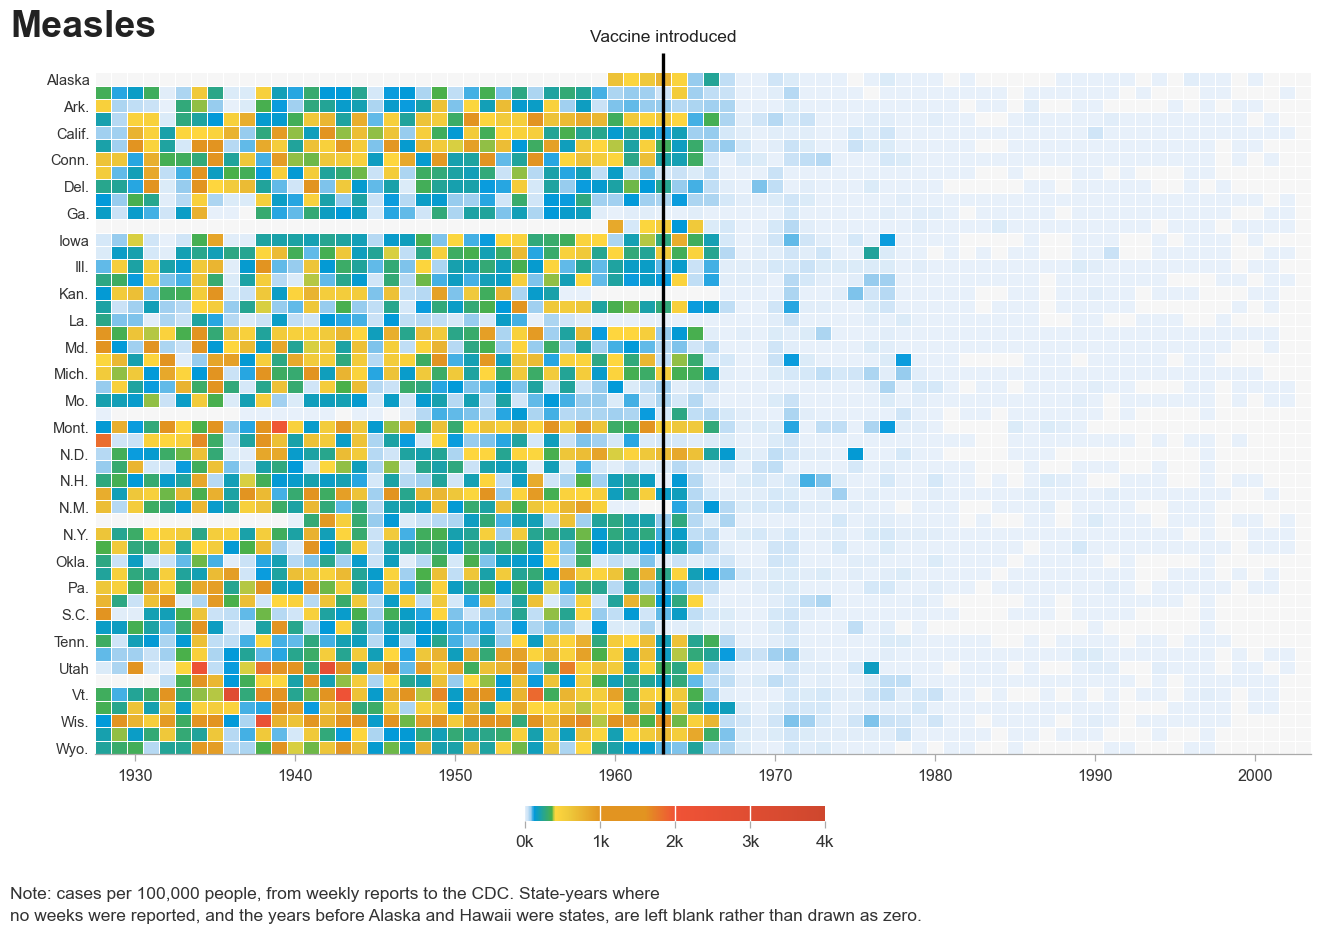

In [8]:
NOTE = ("Note: cases per 100,000 people, from weekly reports to the CDC. State-years where\n"
        "no weeks were reported, and the years before Alaska and Hawaii were states, are left blank rather than drawn as zero.")

fig, ax = heatmap(measles, "Measles", NOTE, mark=1963)
fig.savefig(IMAGES / "measles.png", dpi=100, facecolor="white")
plt.show()

## 7. The other diseases

The same function, unchanged. This is the test of whether the design is a design or a one-off: it
should survive being pointed at data that does not tell as clean a story.

It mostly does, and the failures are informative. **Rubella** and **mumps** are clean but short --
their records only start once the disease became notifiable, so there is little "before" to
compare against. **Pertussis** declines for real, but the record begins in 1938 and the vaccine
arrived around 1948, so the rule has only a decade to cut through. **Smallpox** is the opposite
case: vaccination long predates the data, and what the chart shows is the tail end of an
eradication already in progress, with no rule to draw. **Hepatitis A** has no childhood-vaccine
line worth marking in this window and becomes an ordinary, rather quiet, heat map -- which is the
honest outcome.

The scale stays the measles scale throughout, so the rarer diseases come out pale. That is a
deliberate choice; section 8 shows what it costs. And `Polio` is absent, for the reason found in
section 1.

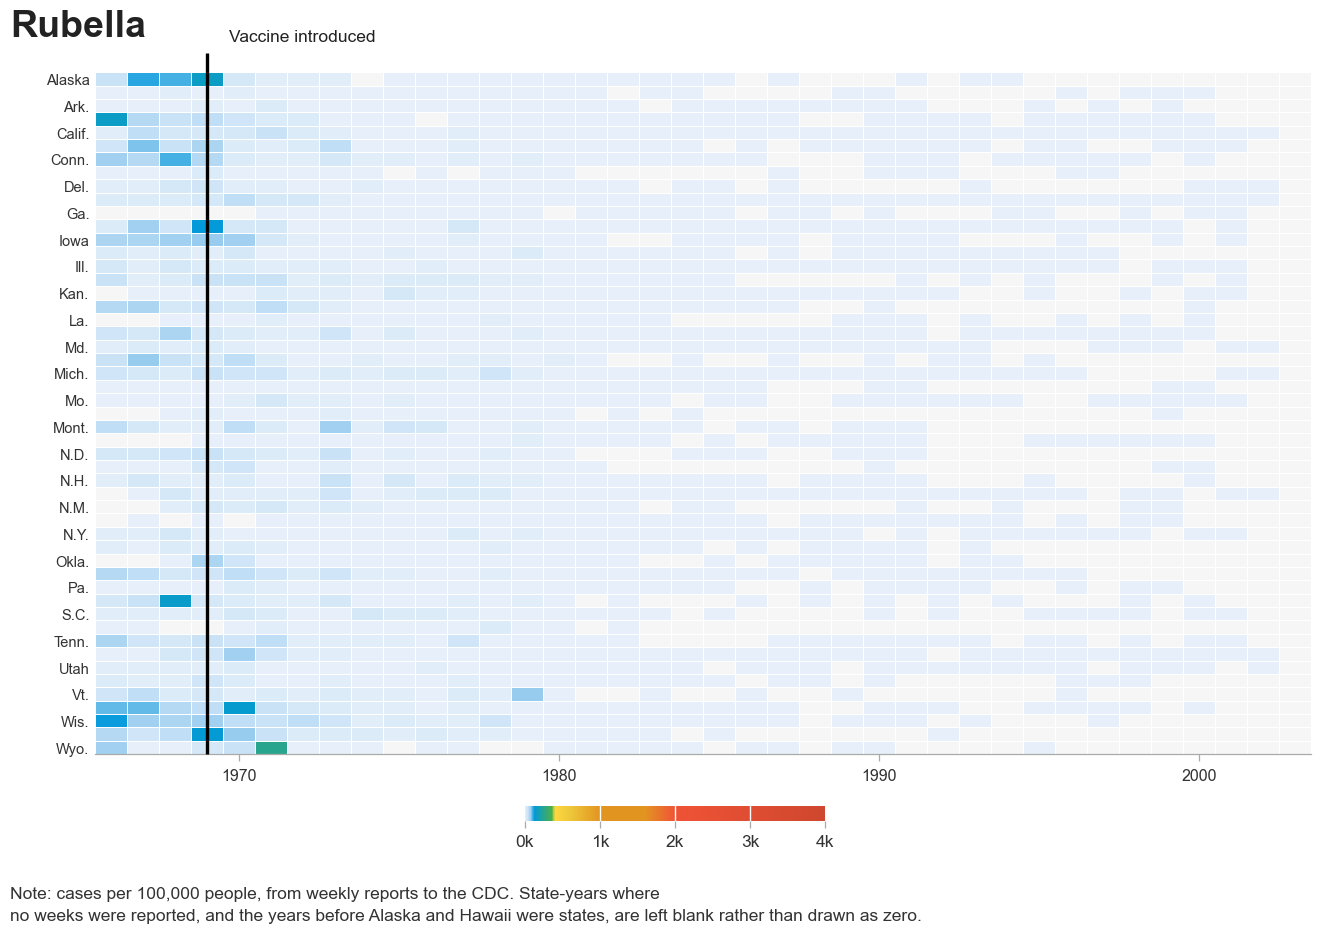

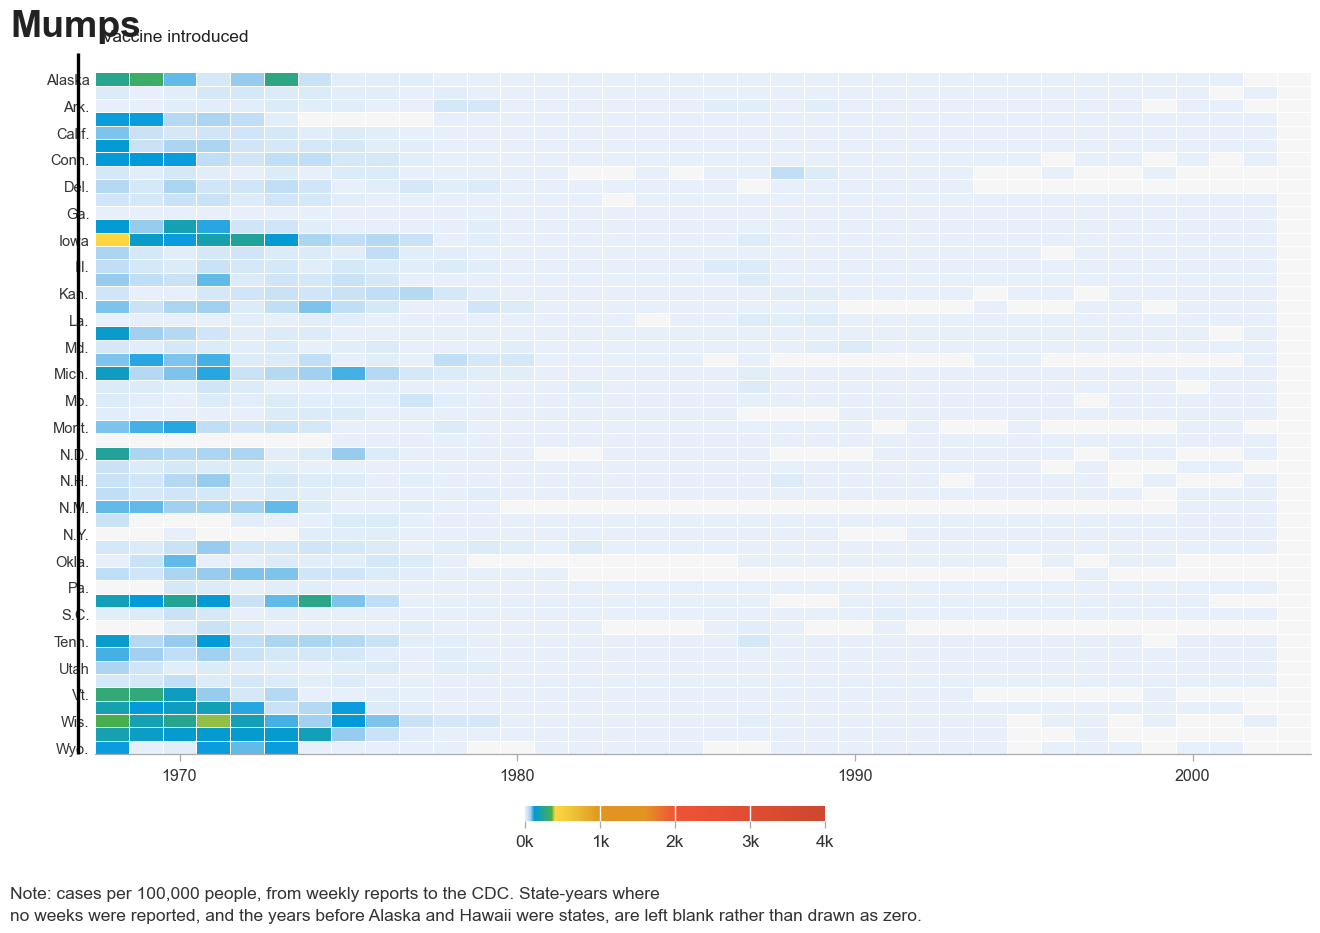

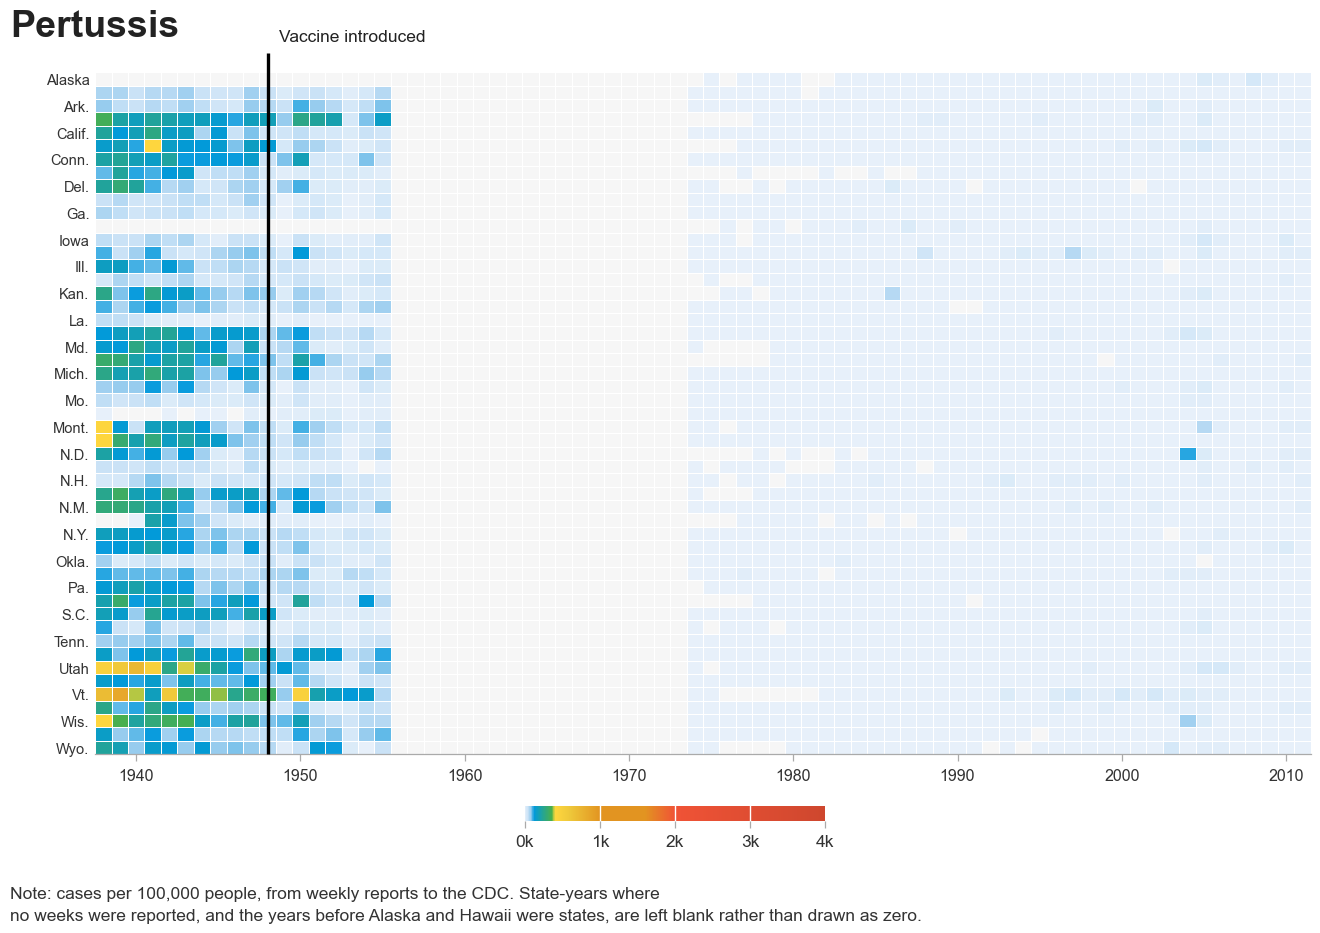

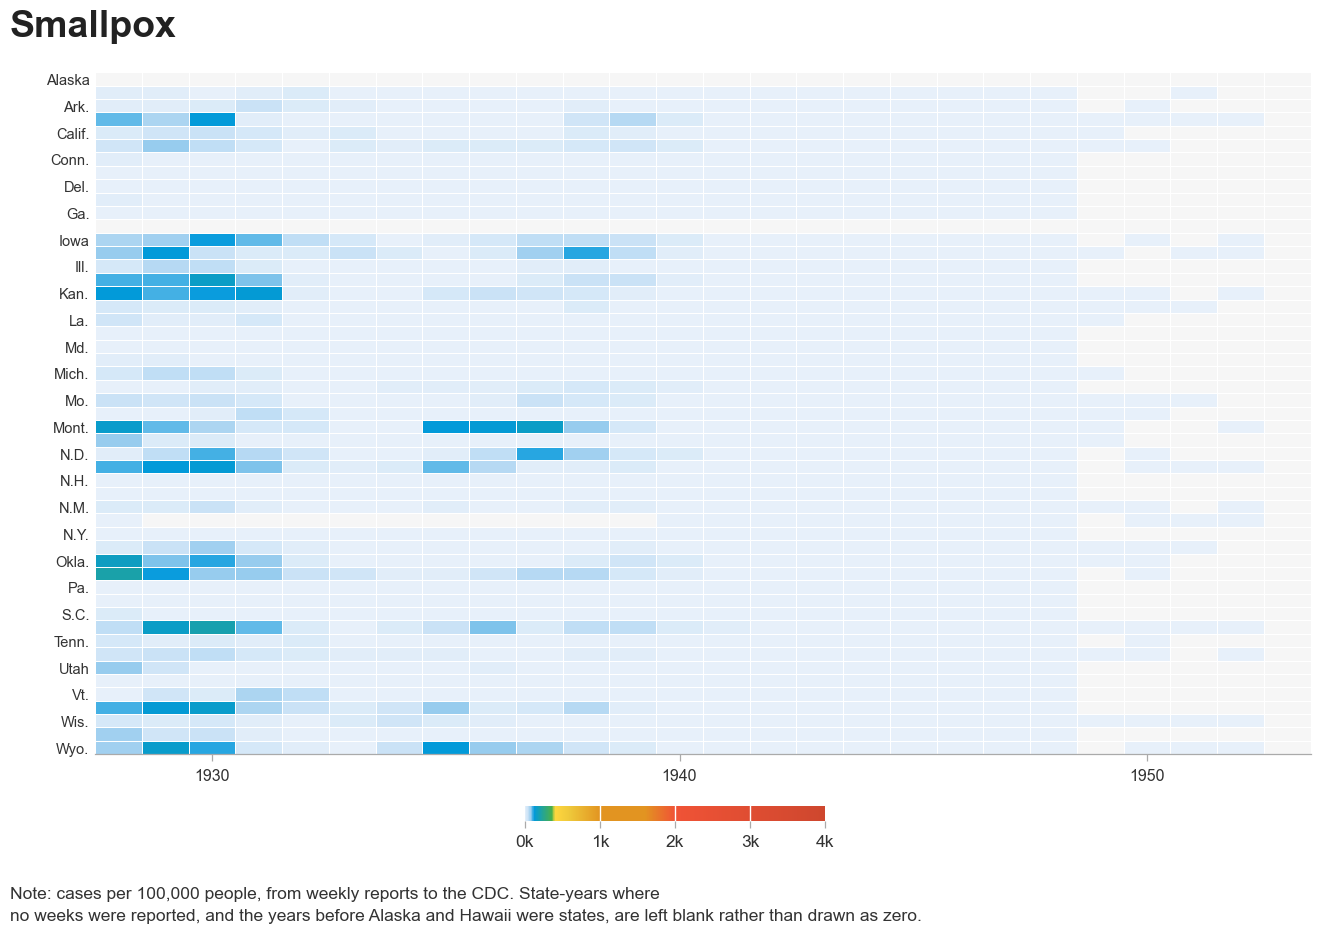

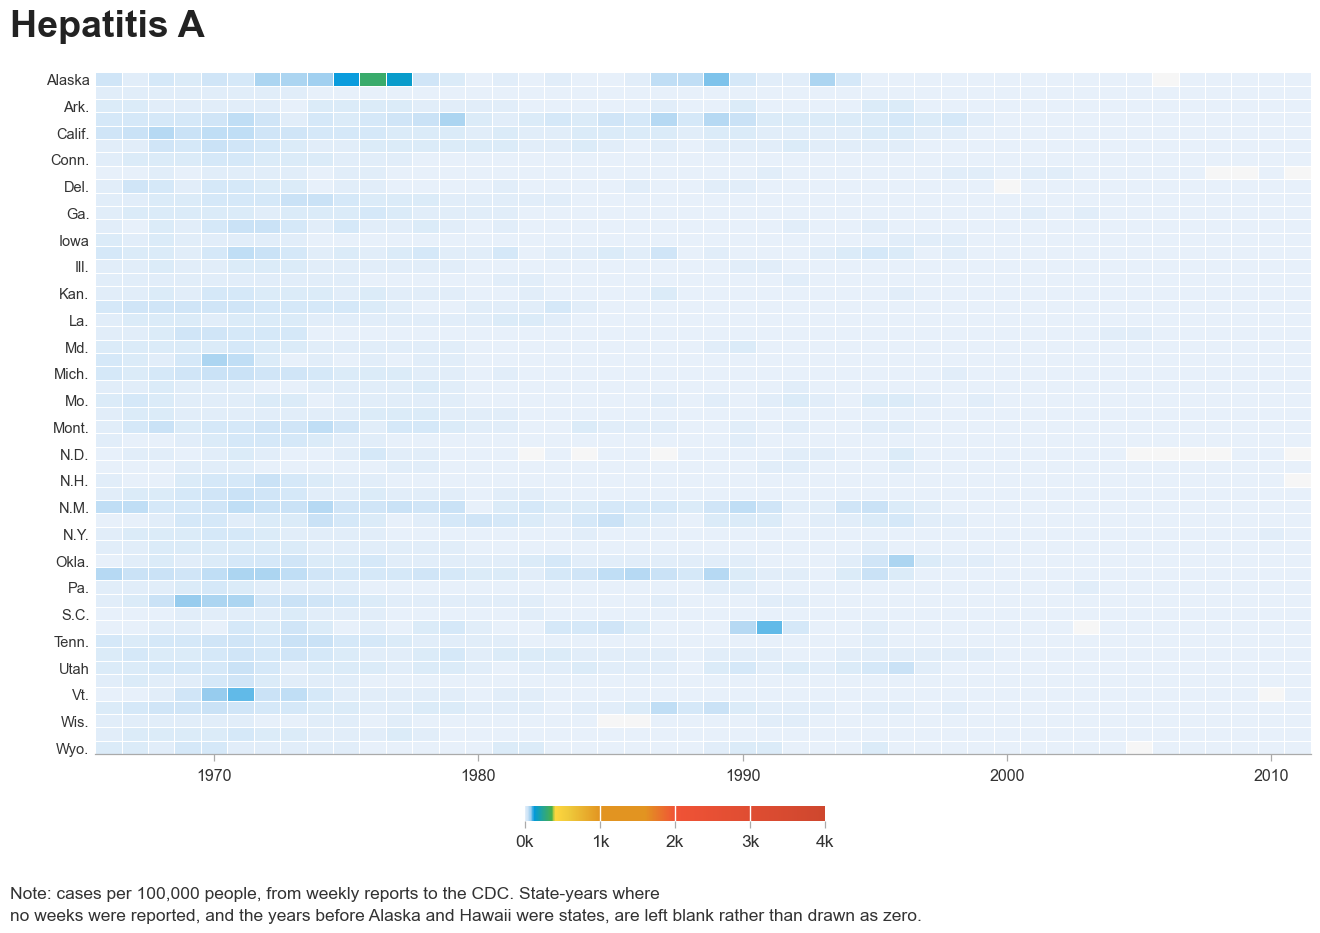

In [9]:
# Licensing years for the routine childhood vaccines, where one falls in range.
# Smallpox vaccination long predates the record, so there is no rule to draw.
VACCINE = {"Mumps": 1967, "Rubella": 1969, "Pertussis": 1948,
           "Smallpox": None, "Hepatitis A": None}

for disease in ["Rubella", "Mumps", "Pertussis", "Smallpox", "Hepatitis A"]:
    wide = grid(disease)
    fig, ax = heatmap(wide, disease, NOTE, mark=VACCINE[disease])
    fig.savefig(IMAGES / ("%s.png" % disease.lower().replace(" ", "_")),
                dpi=100, facecolor="white")
    plt.show()

## 8. What the shared scale costs

Holding every disease on the measles 0-4,000 scale is what makes the panels above *comparable* --
you can see at a glance that measles was an order of magnitude more common than mumps. It also
means the mumps panel is nearly blank and its own internal structure is invisible.

Below, the same mumps data on a scale fitted to itself. Both charts are true. The first answers
"how big was mumps next to measles"; the second answers "when and where was mumps bad". One
picture cannot answer both, and choosing which question to answer is the whole job.

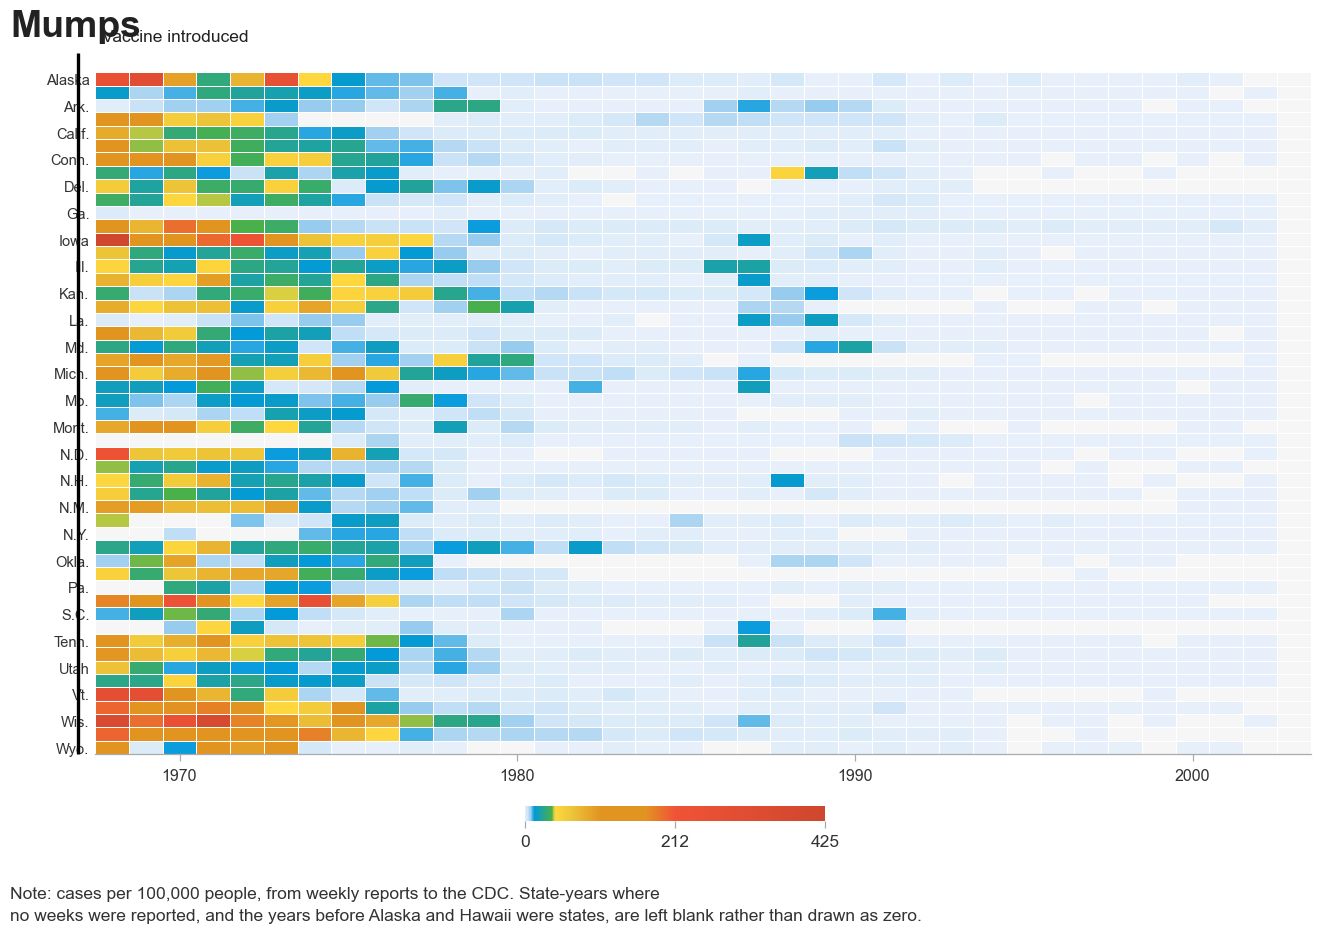

mumps peaks at 425 per 100,000; measles at 2964 -- a factor of 7


In [10]:
mumps = grid("Mumps")
own_max = float(np.nanmax(mumps.to_numpy()))

fig, ax = heatmap(mumps, "Mumps", NOTE, mark=1967,
                  norm=Normalize(vmin=0, vmax=own_max))
cax = fig.axes[-1]                                   # relabel the bar in its own units
cax.set_xticks([0, own_max / 2, own_max])
cax.set_xticklabels(["0", "%.0f" % (own_max / 2), "%.0f" % own_max])
fig.savefig(IMAGES / "mumps_own_scale.png", dpi=100, facecolor="white")
plt.show()

print("mumps peaks at %.0f per 100,000; measles at %.0f -- a factor of %.0f"
      % (own_max, measles.max().max(), measles.max().max() / own_max))

## 9. Checking the rebuild against the published image

Everything above is a claim about what the WSJ did. `measles_WSJ.jpg` is in this folder, so the
claims are testable: read the colours back out of the published chart, invert them through the
colour scale, and compare with the numbers computed here.

The geometry comes from the image itself -- the nine x-axis tick marks fix the year-to-pixel
mapping, and the fifty-one rows divide the plot band evenly.

cells read off the published chart: 3223
  peak value in the image        2922
  peak of the unscaled rate      2964   <- matches
  peak of the weeks-scaled       3670
  median |image - unscaled|         2


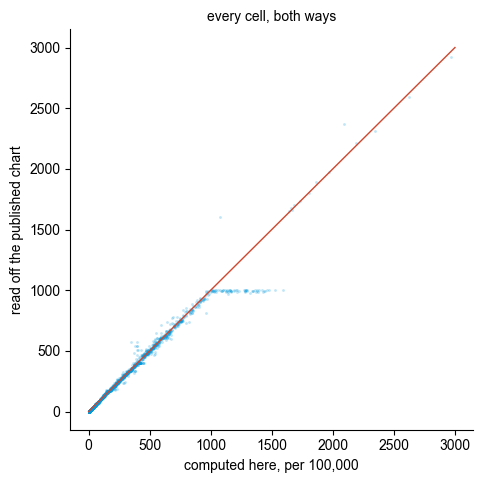

In [11]:
from PIL import Image

ref = np.asarray(Image.open(HERE / "measles_WSJ.jpg").convert("RGB")).astype(float)

# Tick marks at 1930..2010 sit at these pixel columns; rows fill the plot band.
x_of = lambda yr: 135.5 + (yr - 1930) * 14.25
y_of = lambda i: 108.9 + (i + 0.5) * 13.1

lut = np.array([CMAP(i / 2000.0)[:3] for i in range(2001)]) * 255
lut_vals = np.linspace(0, VMAX, 2001)

states = list(measles.index)
read, mine_plain, mine_scaled = [], [], []
for _, r in m.iterrows():                      # m: the measles frame from section 3
    yr = int(r["year"])
    if not (1929 <= yr <= 2002) or not np.isfinite(r["plain"]):
        continue
    x, y = int(round(x_of(yr))), int(round(y_of(states.index(r["state"]))))
    swatch = np.median(ref[y - 3:y + 4, x - 4:x + 5].reshape(-1, 3), axis=0)
    k = int(np.argmin(((lut - swatch) ** 2).sum(axis=1)))
    if np.sqrt(((lut[k] - swatch) ** 2).sum()) > 28:      # JPEG noise / not a cell colour
        continue
    read.append(lut_vals[k])
    mine_plain.append(r["plain"])
    mine_scaled.append(r["scaled"])

read = np.array(read)
print("cells read off the published chart: %d" % len(read))
print("  peak value in the image      %6.0f" % read.max())
print("  peak of the unscaled rate    %6.0f   <- matches" % np.nanmax(mine_plain))
print("  peak of the weeks-scaled     %6.0f" % np.nanmax(mine_scaled))
print("  median |image - unscaled|    %6.0f" % np.median(np.abs(read - mine_plain)))

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.scatter(mine_plain, read, s=4, color="#0099dc", alpha=0.25, linewidths=0)
ax.plot([0, 3000], [0, 3000], color="#ce472e", lw=1)
ax.set_xlabel("computed here, per 100,000")
ax.set_ylabel("read off the published chart")
ax.set_title("every cell, both ways", size=10)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.show()

On the line, cell for cell. The rebuild is the same chart.

## Notes on the reproduction

**Where this differs from the published version.** The WSJ panel runs to 2012; `us_diseases.csv`
stops at 2003 for measles, so the right-hand eighth of the original -- the long pale tail -- is
missing here. The original's footnote explains that its 2003-2012 values come from the CDC's
*Summary of Notifiable Diseases*, which publishes yearly rather than weekly and counts confirmed
rather than provisional cases. That is a real seam in the data, and it is worth noticing that the
newspaper disclosed it in a footnote rather than hiding it or quietly dropping the years. The note
under our chart says what is true of our chart instead.

**Design decisions that carried the chart, in order of how much they mattered:**

1. Rates, not counts. Without this the chart is a population map.
2. Blanks for unreported years, not zeros.
3. Non-linear colour stops on a linear axis. Without them the chart is blank.
4. `weeks_reporting` used to exclude, never to adjust.
5. One rule, in black, labelled in words.

Only the third is a *drawing* decision. The others are decisions about what number goes in the
cell, or whether a number goes in it at all -- which is where most of the work in most charts
actually is.